In [1]:
import pylablib as pll
pll.par["devices/dlls/andor_shamrock"] = "C:/Program Files/Andor SDK/Shamrock64"
pll.par["devices/dlls/andor_sdk2"] = "C:/Program Files/Andor SDK"
from pylablib.devices import Andor

import time
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from thorlabs_elliptec import ELLx, ELLError, ELLStatus, list_devices
import thorlabs_elliptec
print(list_devices())
# Prints something like:
# device=/dev/ttyUSB1, manufacturer=Prolific Technology Inc., product=USB-Serial Controller, vid=0x067b, pid=0x2303, serial_number=None, location=1-1.1

In [25]:
# Initialize
cam = Andor.AndorSDK2Camera(temperature=-75, fan_mode="full") # Cooling setpoint
spec = Andor.ShamrockSpectrograph()
cam.setup_shutter("auto")
cam.set_read_mode("fvb")

In [ ]:
# Check the cooling temperature
cam.get_temperature()
cam.get_temperature_status()

# Parameters

In [29]:
# Set Grating
spec.set_grating(2) # 1 for 150, 2 for 1200
spec.set_grating_offset(-32) # -25 for 150, -32 for 1200?

# Laser wavelength in nm
laser_wavelength = 532 

# Exposure time in sec
exposure_time = 0.5 
cam.set_exposure(exposure_time)

# Spectrum center and unit (nm, eV, cm-1)
center_value = 1370
unit = "cm-1"

def center_setting(center = center_value, Unit=unit, ex_wavelength=laser_wavelength):
    """Set spectrograph center wavelength."""
    if Unit == "nm":
        center_wavelength = center
    elif Unit == "eV":
        center_wavelength = 1240 / center
    elif Unit == "cm-1":
        center_wavelength = 1 / ((1 / ex_wavelength) - center / 1e7)
    else:
        raise ValueError("unit must be 'nm', 'eV', or 'cm-1'")
    
    spec.set_wavelength(center_wavelength * 1e-9)  # convert to meters

center_setting()

# Create value for x-axis
spec.setup_pixels_from_camera(cam) # setup camera sensor parameters (number and size of pixels) for wavelength calibration

# Unit convertion
wavelengths = spec.get_calibration()*(10**9) # Get x-axis value in nm
photo_energy = 1240/wavelengths # Get x-axis value in eV
raman_shift = (10**7)*(1/laser_wavelength-1/wavelengths) # Get x-axis value in cm-1

-32

# Mesurement

In [ ]:
# --- Acquire single frame ---
frame = cam.snap()
spectrum = frame.mean(axis=0) if frame.ndim > 1 else frame

# --- X-axis trimming ---
x_nm = wavelengths[:len(spectrum)]
x_eV = photo_energy[:len(spectrum)]
x_cm = raman_shift[:len(spectrum)]

# --- Plot in nm ---
plt.figure()
plt.plot(x_nm, spectrum, lw=1.5)
plt.xlabel("Wavelength (nm)")
plt.ylabel("Intensity (a.u.)")
plt.title("PL Spectrum (nm)")
plt.show()

# --- Plot in eV ---
plt.figure()
plt.plot(x_eV, spectrum, lw=1.5)
plt.gca().invert_xaxis()
plt.xlabel("Energy (eV)")
plt.ylabel("Intensity (a.u.)")
plt.title("PL Spectrum (eV)")
plt.show()

# --- Plot in Raman shift ---
plt.figure()
plt.plot(x_cm, spectrum, lw=1.5)
plt.xlabel("Raman Shift (cm⁻¹)")
plt.ylabel("Intensity (a.u.)")
plt.title("Raman Spectrum")
plt.show()

"""
np.savetxt(f"PL_spectrum_nm_Exp{exposure_time}sec.txt", np.column_stack([x_nm, spectrum]),
           header="Wavelength (nm)\tIntensity (a.u.)")
np.savetxt(f"PL_spectrum_eV_Exp{exposure_time}sec.txt", np.column_stack([x_eV, spectrum]),
           header="Energy (eV)\tIntensity (a.u.)")
np.savetxt(f"Raman_spectrum_Exp{exposure_time}sec.txt", np.column_stack([x_cm, spectrum]),
           header="Raman shift (cm-1)\tIntensity (a.u.)")
"""
# Save data
np.savetxt(f"Spectrum_Exp{exposure_time}sec.txt", np.column_stack([x_nm, x_eV, x_cm, spectrum]),
           header="Wavelength (nm)\tEnergy (eV)\tRaman shift(cm-1)\tIntensity (a.u.)")

In [24]:
# Execute before end the code
spec.close()
cam.close()

# Polarization dependence test

# The Code End Here

In [30]:
# Parameter setting
spec.set_wavelength(574E-9) # Set center wavelength
cam.set_exposure(0.5) # Exposure time (sec)

spec.setup_pixels_from_camera(cam) # setup camera sensor parameters (number and size of pixels) for wavelength calibration
wavelengths = spec.get_calibration()  # return array of wavelength corresponding to each pixel

In [31]:
print("Exposure time: ", cam.get_exposure(), "sec")
print("Center Wavelength: ", spec.get_wavelength(), "nm")
print(spec.get_grating())
print(spec.get_grating_offset())

2
0.5
5.74e-07
-32


[1.62439618e-06 1.62449469e-06 1.62459302e-06 ... 1.81752997e-06
 1.81762463e-06 1.81771912e-06]


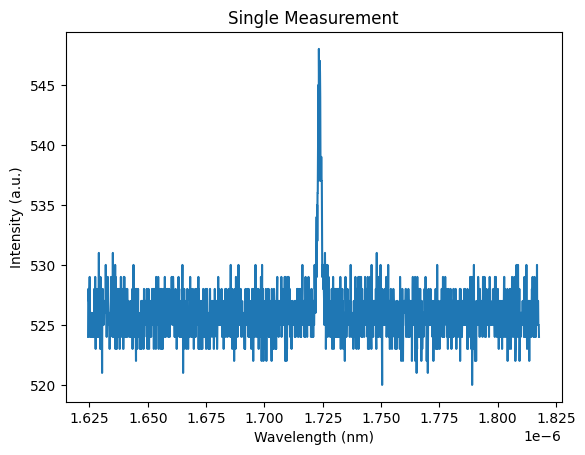

In [39]:
# Get wavelength calibration
wavelengths = spec.get_calibration()
wavelengths = wavelengths*(10**9)

# --- Acquire single frame ---
spectrum = cam.snap()
#frame = cam.snap()
#spectrum = frame.mean(axis=0) if frame.ndim > 1 else frame

# --- Plot result ---
plt.figure()
plt.plot(wavelengths[: len(spectrum)], spectrum, lw=1.5)
plt.xlabel("Wavelength (nm)")
plt.ylabel("Intensity (a.u.)")
#plt.title("Single Measurement")
plt.show()

In [20]:
spectrum = cam.snap()[0]  # 1D array of the corresponding spectrum intensities
print(spectrum)

[523 528 524 ... 526 525 527]


In [6]:
cam.start_acquisition()
frame = cam.grab(1)

In [15]:
print(wavelengths)

[5.05659241e-07 5.05953827e-07 5.06248444e-07 ... 1.09284717e-06
 1.09313940e-06 1.09343164e-06]


In [8]:
print(spectrum)

[526 528 527 ... 532 528 526]


In [9]:
print(frame)

[array([[525, 528, 526, ..., 526, 525, 527]], dtype=uint16)]


In [10]:
help(cam.grab)

Help on method grab in module pylablib.devices.interface.camera:

grab(nframes=1, frame_timeout=5.0, missing_frame='skip', return_info=False, buff_size=None) method of pylablib.devices.Andor.AndorSDK2.AndorSDK2Camera instance
    Snap `nframes` images (with preset image read mode parameters)
    
    `buff_size` determines buffer size (if ``None``, use the default size).
    Timeout is specified for a single-frame acquisition, not for the whole acquisition time.
    `missing_frame` determines what to do with frames which have been lost:
    can be ``"none"`` (replacing them with ``None``), ``"zero"`` (replacing them with zero-filled frame),
    or ``"skip"`` (skipping them, while still keeping total returned frames number to `n`).
    If ``return_info==True``, return tuple ``(frames, infos)``, where ``infos`` is a list of frame info tuples (camera-dependent);
    if some frames are missing and ``missing_frame!="skip"``, the corresponding frame info is ``None``.



In [11]:
help(cam.snap)

Help on method snap in module pylablib.devices.interface.camera:

snap(timeout=5.0, return_info=False) method of pylablib.devices.Andor.AndorSDK2.AndorSDK2Camera instance
    Snap a single frame



In [12]:
help(spec.set_grating)

Help on method set_grating in module pylablib.devices.Andor.Shamrock:

set_grating(grating, force=False) method of pylablib.devices.Andor.Shamrock.ShamrockSpectrograph instance
    Set current grating (counting from 1)
    
    Call blocks until the grating is exchanged (up to 10-20 seconds).
    If ``force==False`` and the current grating index is the same as requested, skip the call;
    otherwise, call the grating set command regardless (takes about a second in the grating is unchanged).



In [8]:
cam.get_all_amp_modes()

[TAmpModeFull(channel=0, channel_bitdepth=16, oamp=0, oamp_kind='Conventional', hsspeed=0, hsspeed_MHz=1.4800000190734863, preamp=0, preamp_gain=1.0),
 TAmpModeFull(channel=0, channel_bitdepth=16, oamp=0, oamp_kind='Conventional', hsspeed=0, hsspeed_MHz=1.4800000190734863, preamp=1, preamp_gain=2.0),
 TAmpModeFull(channel=0, channel_bitdepth=16, oamp=0, oamp_kind='Conventional', hsspeed=0, hsspeed_MHz=1.4800000190734863, preamp=2, preamp_gain=4.0),
 TAmpModeFull(channel=0, channel_bitdepth=16, oamp=0, oamp_kind='Conventional', hsspeed=1, hsspeed_MHz=0.4000000059604645, preamp=0, preamp_gain=1.0),
 TAmpModeFull(channel=0, channel_bitdepth=16, oamp=0, oamp_kind='Conventional', hsspeed=1, hsspeed_MHz=0.4000000059604645, preamp=1, preamp_gain=2.0),
 TAmpModeFull(channel=0, channel_bitdepth=16, oamp=0, oamp_kind='Conventional', hsspeed=1, hsspeed_MHz=0.4000000059604645, preamp=2, preamp_gain=4.0),
 TAmpModeFull(channel=0, channel_bitdepth=16, oamp=0, oamp_kind='Conventional', hsspeed=2, hss

In [10]:
cam.get_max_vsspeed()

1

In [12]:
Andor.get_cameras_number_SDK2()

1

In [11]:
Andor.list_shamrock_spectrographs()

['KY-3764']

In [5]:
spec.get_wavelength()

4.5000000000000003e-07

In [14]:
help(cam)

Help on AndorSDK2Camera in module pylablib.devices.Andor.AndorSDK2 object:

class AndorSDK2Camera(pylablib.devices.interface.camera.IBinROICamera, pylablib.devices.interface.camera.IExposureCamera)
 |  AndorSDK2Camera(idx=0, ini_path='', temperature=None, fan_mode='off', amp_mode=None)
 |  
 |  Andor SDK2 camera.
 |  
 |  Due to the library features, the camera needs to set up all of the parameters to some default values upon connection.
 |  Most of these parameters are chosen as reasonable defaults: full ROI, minimal exposure time, closed shutter,
 |  internal trigger, fastest recommended verticals shift speed, no EMCCD gain.
 |  However, some should be supplied during the connection: temperature setpoint (where appropriate), fan mode, and amplifier mode;
 |  while there is still a possibility to have default values of these parameters, they might not be appropriate in some settings, and frequently need to be changed.
 |  
 |  Caution: the manufacturer DLL is designed such that if the

In [15]:
help(spec)

Help on ShamrockSpectrograph in module pylablib.devices.Andor.Shamrock object:

class ShamrockSpectrograph(pylablib.core.devio.interface.IDevice)
 |  ShamrockSpectrograph(idx=0)
 |  
 |  Shamrock spectrograph.
 |  
 |  Args:
 |      idx(int): spectrograph index (starting from 0; use :func:`list_spectrographs` to get the list of all connected spectrographs)
 |  
 |  Method resolution order:
 |      ShamrockSpectrograph
 |      pylablib.core.devio.interface.IDevice
 |      builtins.object
 |  
 |  Methods defined here:
 |  
 |  __init__(self, idx=0)
 |      Initialize self.  See help(type(self)) for accurate signature.
 |  
 |  close(self)
 |      Close the connection
 |  
 |  get_accessory_state(self, line)
 |      Get current accessory state on a given line (1 or 2)
 |  
 |  get_calibration(self)
 |      Get wavelength calibration.
 |      
 |      Return numpy array which specifies wavelength (in m) corresponding to each pixel.
 |      Prior to calling this method, the total number of

In [2]:
print(10^9)
print(10**9)

3
1000000000
